# Exploratory Data Analysis

In [1]:
import pandas as pd

train = pd.read_csv("../data/train_test.csv", parse_dates=["date"])
val = pd.read_csv("../data/validation.csv", parse_dates=["date"])

train = pd.read_csv("../data/train_test.csv", parse_dates=["date"])
val = pd.read_csv("../data/validation.csv", parse_dates=["date"])

print(train.shape, val.shape)
print("train:", train["date"].min(), "->", train["date"].max())
print("val:  ", val["date"].min(), "->", val["date"].max())

(48000, 14) (12000, 13)
train: 2025-01-01 00:00:00 -> 2025-10-31 00:00:00
val:   2025-11-01 00:00:00 -> 2025-12-31 00:00:00


train: 1 january - 31 october 2025 - 48.000 loads and 10 months  
validation: 1 november - 31 december 2025 - 12.000 loads and 2 months  
no overlap - validation starts after train ends  
validation doesnt have posted_rate column - 13 vs 14 columns  

DECISION: The validation is right after the train ends and there is no overlap. The final validation will be completely new dates. Since the job is predicting the future, the train must be similiar: training with the first months, and testing with the last months.

delivery_lon   -0.257086
pickup_lon     -0.255058
delivery_lat   -0.091970
pickup_lat     -0.090873
quote_signal   -0.039858
market_index    0.034165
weight          0.034840
distance        0.908519
posted_rate     1.000000
Name: posted_rate, dtype: float64


<Axes: xlabel='distance', ylabel='posted_rate'>

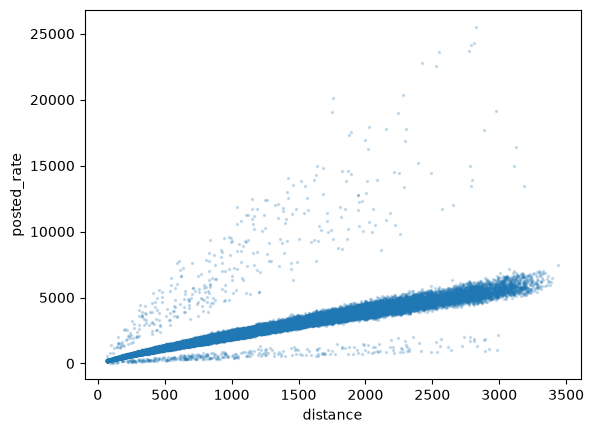

In [2]:
print(train.corr(numeric_only=True)["posted_rate"].sort_values())
train.plot.scatter(x="distance", y="posted_rate", s=2, alpha=0.2)

distance has 0.91 correlation with posted_rate: very strong  
longitude is weak: around -0.26  
latitude, weight, market_index and quote_signal are close to zero  
the plot shows one thick band: rate goes up as distance goes up

There is two suspicious groups i will check later:  
the cloud above the band: much more expensive loads for the same distance  
the thin line below the band: very cheap loads for the same distance

count    48000.000000
mean         2.215347
std          0.583887
min          0.333709
25%          1.986974
50%          2.145348
75%          2.342696
max         14.125294
Name: rate_per_mile, dtype: float64


equipment
Dry Van    2.046203
Flatbed    2.219683
Reefer     2.311540
Name: rate_per_mile, dtype: float64


<Axes: ylabel='Frequency'>

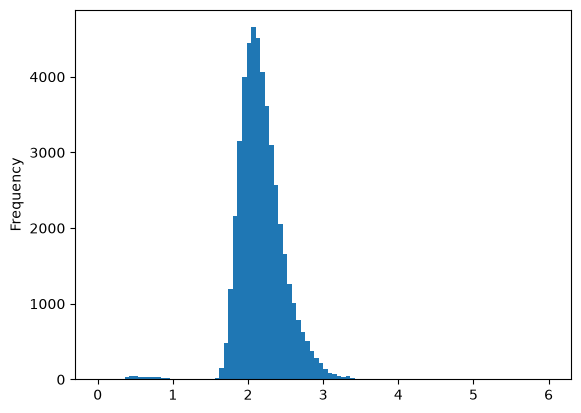

In [3]:
train["rate_per_mile"] = train["posted_rate"] / train["distance"]

print(train["rate_per_mile"].describe())
print("\n")
print(train.groupby("equipment")["rate_per_mile"].median())

train["rate_per_mile"].plot.hist(bins=100, range=(0, 6))

typical rate per mile is 2.15 dollars
half of the loads are between 1.99 and 2.34: very narrow
min is 0.33 and max is 14.13: far from the typical value

rate per mile is much more stable than the raw rate, almost always around 2.
equipment changes the price a bit, reefer is the most expensive.
the small bump on the left of the histogram is the thin line i saw in the scatter plot.

but there is still a difference between loads with the same distance and equipment. i want to see if the city or the route explains it.

### Location?

In [4]:
print(train.groupby("pickup")["rate_per_mile"].median().sort_values())

pickup
Reno             1.947583
San Francisco    1.961830
Fresno           1.996801
Los Angeles      1.997495
Phoenix          1.999630
                   ...   
Louisville       2.263630
Nashville        2.273804
Memphis          2.275539
Atlanta          2.285634
Chattanooga      2.290721
Name: rate_per_mile, Length: 64, dtype: float64


the city affects the price

In [5]:
train_cities = set(train["pickup"]) | set(train["delivery"])
val_cities = set(val["pickup"]) | set(val["delivery"])

print("train cities length:", len(train_cities))
print("val cities length:", len(val_cities))
print("cities that are just in validation:", (val_cities - train_cities))

train cities length: 64
val cities length: 72
cities that are just in validation: {'Norfolk', 'Allentown', 'Chicago', 'Charlotte', 'Knoxville', 'San Diego', 'Laredo', 'Jackson'}


In [6]:
train_lanes = set(zip(train["pickup"], train["delivery"]))
val_lanes = set(zip(val["pickup"], val["delivery"]))

print("train lanes length:", len(train_lanes))
print("val lanes length:", len(val_lanes))
print("lanes that are just in validation:", len(val_lanes - train_lanes))

train lanes length: 4014
val lanes length: 4214
lanes that are just in validation: 736


train has 64 cities and validation has 72  
8 cities are only in validation  
736 lanes are only in validation  

the model will never see these cities in training.
so i cant use the city name alone. i want to see if there is something behind the city name that also works for new cities.

<Axes: xlabel='longitude', ylabel='latitude'>

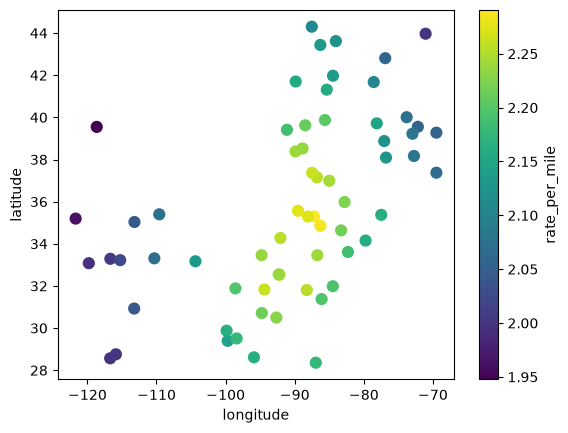

In [7]:
city = train.groupby("pickup").agg(
    latitude=("pickup_lat", "first"),
    longitude=("pickup_lon", "first"),
    rate_per_mile=("rate_per_mile", "median"),
)

city.plot.scatter(x="longitude", y="latitude", c="rate_per_mile", colormap="viridis", s=60)

i dont know these cities so i plotted them by their coordinates and colored by rate per mile
similar colors are together:  

cities on the left are the cheapest  
cities in the middle are the most expensive  
cities on the top right are in between  

so the rate depends on the location, cities close to each other have similar rates.  

DECISION: The model can use the coordinates since this also works for the new cities.

#### Coordinates quality check

In [8]:
all_loads = pd.concat([train, val])
coordinates_per_city = all_loads.groupby("pickup")[["pickup_lat", "pickup_lon"]].nunique()

if (coordinates_per_city == 1).all().all():
    print("every city has one coordinate.")
else:
    print("some cities have more than one coordinate.")

every city has one coordinate.


In [9]:
pickup_coordinates = all_loads.groupby("pickup")[["pickup_lat", "pickup_lon"]].first()
delivery_coordinates = all_loads.groupby("delivery")[["delivery_lat", "delivery_lon"]].first()


if (pickup_coordinates.values == delivery_coordinates.values).all():
    print("pickup and delivery coordinates are the same.")
else:
    print("pickup and delivery coordinates differ for some cities.")

pickup and delivery coordinates are the same.


In [10]:
coordinate_columns = ["pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon"]
missing_coordinates = all_loads[coordinate_columns].isna().sum().sum()

if missing_coordinates == 0:
    print("no missing coordinates.")
else:
    print("missing coordinates:", missing_coordinates)

no missing coordinates.


In [11]:
import numpy as np


def haversine_miles(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    h = (
        np.sin((lat2 - lat1) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    )
    return 3958.8 * 2 * np.arcsin(np.sqrt(h))


for df in [train, val]:
    straight = haversine_miles(
        df["pickup_lat"], df["pickup_lon"], df["delivery_lat"], df["delivery_lon"]
    )
    df["distance_ratio"] = df["distance"] / straight

print(
    pd.DataFrame(
        {
            "train": train["distance_ratio"].describe(),
            "val": val["distance_ratio"].describe(),
        }
    ).round(2)
)
print("\n")
real_coordinates = pd.DataFrame(
    {"real_lat": [34.05, 39.29, 33.75], "real_lon": [-118.24, -76.61, -84.39]},
    index=["Los Angeles", "Baltimore", "Atlanta"],
)
print(pickup_coordinates.join(real_coordinates, how="inner").round(2))

          train       val
count  48000.00  12000.00
mean       1.19      1.22
std        0.14      1.24
min        1.06      1.10
25%        1.16      1.16
50%        1.18      1.18
75%        1.20      1.21
max        9.63     78.50


             pickup_lat  pickup_lon  real_lat  real_lon
Atlanta           34.85      -86.29     33.75    -84.39
Baltimore         38.17      -72.75     39.29    -76.61
Los Angeles       28.57     -116.70     34.05   -118.24


distance is about 1.18 times the straight line distance between the two cities (median, half of the loads between 1.16 and 1.20). roads are normally around 1.2 times longer than a straight line, so coordinates and distance agree.

but the coordinates are not the real ones, every city is shifted a bit on the map.

In [12]:
print(
    "ratio > 1.6 -> train:",
    (train["distance_ratio"] > 1.6).sum(),
    "val:",
    (val["distance_ratio"] > 1.6).sum(),
)

ratio > 1.6 -> train: 111 val: 34


a few loads have a distance much longer than their straight line: their distance is wrong.

DECISION: the quality checks shows that  the coordinates are consistent and i can use them as features to show which cities are close to each other, not with real map data. the december file has no coordinates, but every city has one fixed coordinate, so i fill them from the city name. i will handle the loads with a wrong distance in the cleaning step.

### Date?

<Axes: xlabel='date'>

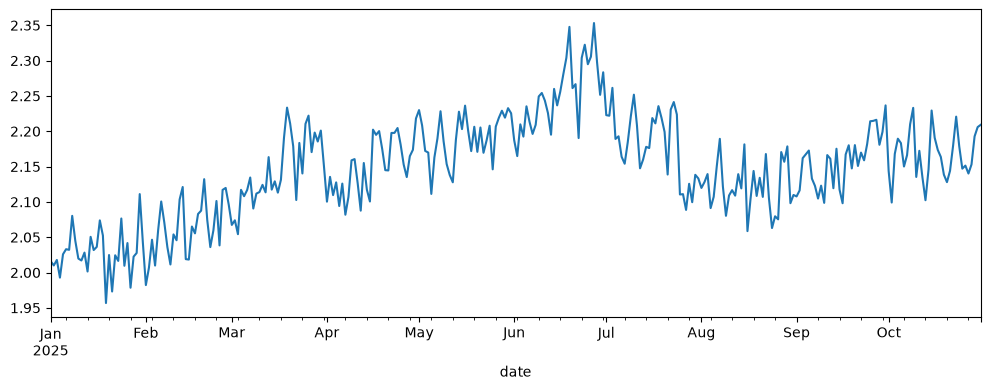

In [13]:
daily_rate = train.groupby("date")["rate_per_mile"].median()

daily_rate.plot(figsize=(12, 4))

rate per mile changes over time  
the date matters, it must be in the model.  
i dont have november and december in the training data, so the last months are my best hint for them.  
this also supports the time-based split: the price level moves from month to month.  

In [14]:
train["day_of_week"] = train["date"].dt.day_name()

print(train.groupby("day_of_week")["rate_per_mile"].median().sort_values())

day_of_week
Monday       2.126141
Sunday       2.127364
Saturday     2.131724
Tuesday      2.139350
Friday       2.157178
Wednesday    2.163024
Thursday     2.170587
Name: rate_per_mile, dtype: float64


the effect is small compared to equipment, city and month.
i will still add day of week as a feature and check in modeling if it helps. it costs nothing and the model can ignore it if it doesnt help.

In [15]:
print(
    "missing weight -> train:",
    train["weight"].isna().sum(),
    "val:",
    val["weight"].isna().sum(),
)
print(
    "negative weight -> train:",
    (train["weight"] < 0).sum(),
    "val:",
    (val["weight"] < 0).sum(),
)

outlier = (train["rate_per_mile"] < 1) | (train["rate_per_mile"] > 3.5)
print("extreme rate per mile:", outlier.sum())
print("\ndistribution by month:")
print(train[outlier].groupby(train["date"].dt.month).size())

missing weight -> train: 300 val: 165
negative weight -> train: 292 val: 145
extreme rate per mile: 671

distribution by month:
date
1     81
2     55
3     71
4     66
5     61
6     62
7     65
8     66
9     65
10    79
dtype: int64


some loads have no weight, and some have a negative weight. a negative weight is impossible, so these values are wrong. i cant verify what the real weight was.

the very cheap and very expensive loads are spread evenly over all months. there is no pattern behind them, so the model cannot learn when they happen. they look like noise.

DECISION: negative weight is treated as missing, same as the empty ones. weight barely affects the price, so this costs almost nothing. the very cheap and very expensive loads and the loads with a wrong distance are removed from training only. every validation load still gets a prediction.

### Market index and quote signal ?

<Axes: xlabel='market_index', ylabel='rate_per_mile'>

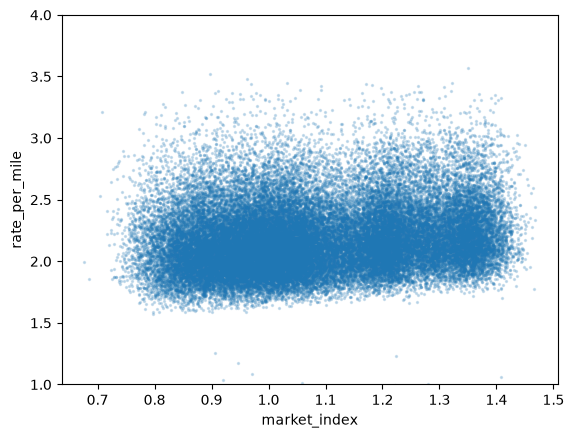

In [16]:
train.plot.scatter(x="market_index", y="rate_per_mile", s=2, alpha=0.2, ylim=(1, 4))

market_index doesnt tell anything about the price

<Axes: xlabel='quote_signal', ylabel='rate_per_mile'>

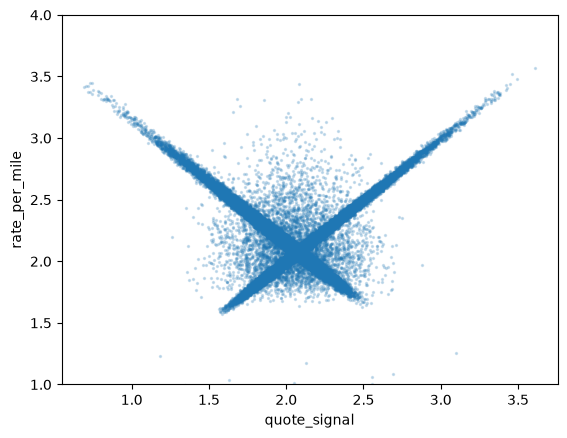

In [17]:
train.plot.scatter(x="quote_signal", y="rate_per_mile", s=2, alpha=0.2, ylim=(1, 4))

the quote_signal plot looks like an X, this is strange  
the relation flips direction from month to month  
i dont know which way it will go in november and december, so i cant trust it.

DECISION: I will not use market_index and quote_signal. market_index has no relation with the price, and quote_signal flips direction every few months. Both are also missing in the december file, so the model will only use features that exist there too.